<a href="https://colab.research.google.com/github/saraivacode/ml_its_slicing/blob/main/deep_its_fv4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import time

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# --- PASSO 1: Certifique-se de que o Drive está montado ---
# Se ainda não montou, execute esta célula primeiro:
# from google.colab import drive
# drive.mount('/content/drive')
# Siga as instruções de autorização que aparecerão.
# ---------------------------------------------------------

# --- PASSO 2: Defina o caminho base para seus arquivos no Drive ---
# O caminho começa com /content/drive/MyDrive/ seguido pela estrutura de pastas no seu Drive.
caminho_base = '/content/drive/MyDrive/IpadAir5/vtc2024/'

# --- PASSO 3: Carregue os arquivos usando os caminhos do Colab ---
try:
    df_sim_ohe_copy = pd.read_csv(caminho_base + 'raw_full.csv')
    features = pd.read_csv(caminho_base + 'features.csv')
    labels = pd.read_csv(caminho_base + 'labels.csv')['impact_level']

    # Opcional: Verificar se os DataFrames foram carregados corretamente
    print("Arquivo 'raw_full.csv' carregado com sucesso.")
    print(df_sim_ohe_copy.head()) # Mostra as primeiras linhas

    print("\nArquivo 'features.csv' carregado com sucesso.")
    print(features.head()) # Mostra as primeiras linhas

    print("\nArquivo 'labels.csv' (coluna 'impact_level') carregado com sucesso.")
    print(labels.head()) # Mostra os primeiros valores da Series

except FileNotFoundError:
    print(f"Erro: Arquivo não encontrado. Verifique se o caminho está correto e se o Drive está montado:")
    print(f"Caminho base verificado: {caminho_base}")
    # Você pode listar os arquivos na pasta para depuração:
    # !ls '/content/drive/MyDrive/IpadAir5/vtc2024/'
except Exception as e:
    print(f"Ocorreu um erro ao ler os arquivos: {e}")

Arquivo 'raw_full.csv' carregado com sucesso.
   ohe__app_E  ohe__app_E2  ohe__app_G  ohe__app_S  ohe__approach_FN  \
0         1.0          0.0         0.0         0.0               0.0   
1         1.0          0.0         0.0         0.0               0.0   
2         1.0          0.0         0.0         0.0               0.0   
3         1.0          0.0         0.0         0.0               0.0   
4         1.0          0.0         0.0         0.0               0.0   

   ohe__approach_FQ  ohe__approach_FS  ohe__cat_req_hbmlmp  \
0               0.0               1.0                  0.0   
1               0.0               1.0                  0.0   
2               0.0               1.0                  0.0   
3               0.0               1.0                  0.0   
4               0.0               1.0                  0.0   

   ohe__cat_req_lblllp  ohe__cat_req_mbclcp  ...   pdr_mam  rtt_masd  \
0                  0.0                  0.0  ...  1.016067  3.443629   
1   

In [ ]:
# Análise básica do dataset
import numpy as np
import pandas as pd
from scipy import stats

print("=== Análise do Dataset ===")

# Verificar tipo de features
is_dataframe = isinstance(features, pd.DataFrame)
is_numpy = isinstance(features, np.ndarray)

print(f"\nTipo de features: {'DataFrame' if is_dataframe else 'Numpy array' if is_numpy else 'Outro'}")

# Informações sobre features
print("\n1. Informações sobre features:")
print(f"Formato das features: {features.shape}")
if is_dataframe:
    print(f"Tipos de dados:\n{features.dtypes}")
else:
    print(f"Tipo de dados: {features.dtype}")
print(f"Número de amostras: {features.shape[0]}")
print(f"Número de features: {features.shape[1]}")

# Estatísticas das features
print("\n2. Estatísticas das features:")
if is_dataframe:
    print("Média por feature (primeiras 10):")
    print(features.mean()[:10])
    print("\nDesvio padrão por feature (primeiras 10):")
    print(features.std()[:10])
    print("\nMínimo e máximo:")
    print(f"Mínimo global: {features.min().min()}")
    print(f"Máximo global: {features.max().max()}")
else:
    print("Média por feature (primeiras 10):")
    print(features.mean(axis=0)[:10])
    print("\nDesvio padrão por feature (primeiras 10):")
    print(features.std(axis=0)[:10])
    print("\nMínimo e máximo:")
    print(f"Mínimo global: {features.min()}")
    print(f"Máximo global: {features.max()}")

# Verificar dados faltantes
if is_dataframe:
    missing_values = features.isna().sum().sum()
else:
    missing_values = pd.DataFrame(features).isna().sum().sum()
print(f"\nDados faltantes: {missing_values}")

# Informações sobre labels
print("\n3. Análise das labels:")
print(f"Tipo de labels: {type(labels)}")
print(f"Formato: {labels.shape if hasattr(labels, 'shape') else len(labels)}")
print("Distribuição das classes:")
unique_labels, counts = np.unique(labels, return_counts=True)
for label, count in zip(unique_labels, counts):
    percentage = (count / len(labels)) * 100
    print(f"  Classe {label}: {count} exemplos ({percentage:.1f}%)")

# Verificar balanceamento
print("\n4. Balanceamento do dataset:")
min_count, max_count = min(counts), max(counts)
balance_ratio = min_count / max_count
print(f"Taxa de balanceamento: {balance_ratio:.2f} (1.0 = perfeitamente balanceado)")

# Se for DataFrame, mostrar nomes das colunas
if is_dataframe and hasattr(features, 'columns'):
    print("\n5. Nomes das colunas (features):")
    print(f"Primeiras 10: {list(features.columns[:10])}")
    print(f"Últimas 10: {list(features.columns[-10:])}")

# Correlação entre features (adaptado para DataFrame)
if features.shape[1] <= 50:
    print("\n6. Análise de correlação:")
    if is_dataframe:
        feature_corr = features.corr()
    else:
        feature_corr = pd.DataFrame(features).corr()

    # Encontrar features altamente correlacionadas
    correlated_pairs = []
    for i in range(len(feature_corr.columns)):
        for j in range(i+1, len(feature_corr.columns)):
            if abs(feature_corr.iloc[i, j]) > 0.8:
                correlated_pairs.append((i, j, feature_corr.iloc[i, j]))

    if correlated_pairs:
        print(f"Pares de features altamente correlacionadas (>0.8):")
        for i, j, corr in correlated_pairs[:5]:  # Mostrar primeiros 5
            if is_dataframe:
                print(f"  {feature_corr.columns[i]} e {feature_corr.columns[j]}: {corr:.3f}")
            else:
                print(f"  Feature {i} e {j}: {corr:.3f}")
    else:
        print("Nenhuma correlação alta encontrada entre features")

# Verificar escala das features
print("\n7. Escala das features:")
feature_ranges = []
for i in range(min(10, features.shape[1])):  # Verificar primeiras 10 features
    if is_dataframe:
        feature_min = features.iloc[:, i].min()
        feature_max = features.iloc[:, i].max()
        col_name = features.columns[i] if hasattr(features, 'columns') else f"Feature {i}"
    else:
        feature_min = features[:, i].min()
        feature_max = features[:, i].max()
        col_name = f"Feature {i}"

    feature_range = feature_max - feature_min
    feature_ranges.append(feature_range)
    print(f"{col_name}: range = {feature_range:.3f}")

# Detectar outliers
print("\n8. Detecção de outliers (Z-score > 3):")
for i in range(min(5, features.shape[1])):  # Verificar primeiras 5 features
    if is_dataframe:
        feature_data = features.iloc[:, i]
        col_name = features.columns[i] if hasattr(features, 'columns') else f"Feature {i}"
    else:
        feature_data = features[:, i]
        col_name = f"Feature {i}"

    z_scores = np.abs(stats.zscore(feature_data.dropna() if is_dataframe else feature_data))
    outliers = np.sum(z_scores > 3)
    print(f"{col_name}: {outliers} outliers")

# Informações sobre memória
print("\n9. Uso de memória:")
features_memory = features.memory_usage(deep=True).sum() / (1024 * 1024) if is_dataframe else features.nbytes / (1024 * 1024)
labels_memory = labels.nbytes / (1024 * 1024) if hasattr(labels, 'nbytes') else 0
print(f"Features: {features_memory:.2f} MB")
print(f"Labels: {labels_memory:.2f} MB")

# Amostras para visualização
print("\n10. Primeiras 5 amostras (features):")
if is_dataframe:
    print(features.head(5))
else:
    print(features[:5])
print("\nPrimeiras 10 labels:")
print(labels[:10])

# Análise de sparsidade
print("\n11. Proporção de zeros:")
if is_dataframe:
    zero_count = (features == 0).sum().sum()
    total_elements = features.size
else:
    zero_count = np.count_nonzero(features == 0) if hasattr(features, 'toarray') else np.count_nonzero(features == 0)
    total_elements = features.size
sparsity = zero_count / total_elements
print(f"Proporção de zeros: {sparsity:.2%}")

# Visualização da distribuição de uma feature
print("\n12. Distribuição de uma feature exemplo:")
if is_dataframe:
    sample_feature = features.iloc[:, 0]
    col_name = features.columns[0] if hasattr(features, 'columns') else "Feature 0"
else:
    sample_feature = features[:, 0]
    col_name = "Feature 0"

print(f"{col_name}:")
print(f"Mínimo: {sample_feature.min():.3f}")
print(f"25%: {np.percentile(sample_feature, 25):.3f}")
print(f"Mediana: {np.median(sample_feature):.3f}")
print(f"75%: {np.percentile(sample_feature, 75):.3f}")
print(f"Máximo: {sample_feature.max():.3f}")

# Recomendações baseadas nas análises
print("\n=== RECOMENDAÇÕES ===")
print("1. Normalização:")
if np.std(feature_ranges) > 10:
    print("  ✓ Recomendado usar StandardScaler (grandes diferenças de escala)")
else:
    print("  ⚠ StandardScaler pode ser opcional")

print("\n2. Feature Selection:")
if features.shape[1] > 50:
    print("  ✓ SelectKBest ou PCA recomendado (muitas features)")
    print(f"  Experimente k={int(features.shape[1] * 0.5)} a {int(features.shape[1] * 0.8)}")

print("\n3. Batch Size:")
if len(labels) < 1000:
    print("  ✓ Use batch sizes menores (16-32) para dataset pequeno")
elif balance_ratio < 0.5:
    print("  ✓ Use batch sizes menores (16-32) para classes desbalanceadas")
else:
    print("  ✓ Experimente batch sizes de 32-128")

print("\n4. Regularização:")
if balance_ratio < 0.3:
    print("  ✓ Aumente L2 (0.01-0.05) e dropout (0.4-0.6) para classes muito desbalanceadas")
else:
    print("  ✓ L2 (0.001-0.01) e dropout (0.2-0.4) são adequados")

print("\n5. Arquitetura:")
n_samples = features.shape[0]
if n_samples < 1000:
    print("  ✓ Use arquitetura menor (n1=16-32, n2=8-16)")
elif n_samples < 5000:
    print("  ✓ Use arquitetura média (n1=32-48, n2=16-24)")
else:
    print("  ✓ Arquitetura média a grande é adequada (n1=48-64, n2=24-32)")

# Salvar informações em arquivo (opcional)
with open('dataset_analysis.txt', 'w') as f:
    f.write(f"Dataset Shape: {features.shape}\n")
    f.write(f"Label Distribution: {dict(zip(unique_labels, counts))}\n")
    f.write(f"Balance Ratio: {balance_ratio:.3f}\n")
    f.write(f"Feature Range Std: {np.std(feature_ranges):.3f}\n")
    if is_dataframe and hasattr(features, 'columns'):
        f.write("Column Names:\n")
        for i, col in enumerate(features.columns):
            f.write(f"  {i}: {col}\n")

=== Análise do Dataset ===

Tipo de features: DataFrame

1. Informações sobre features:
Formato das features: (5093, 29)
Tipos de dados:
ohe__app_E             float64
ohe__app_E2            float64
ohe__app_G             float64
ohe__app_S             float64
ohe__approach_FN       float64
ohe__approach_FQ       float64
ohe__approach_FS       float64
ohe__cat_req_hbmlmp    float64
ohe__cat_req_lblllp    float64
ohe__cat_req_mbclcp    float64
ohe__cat_req_mbmlhp    float64
rec_serv               float64
env_car                float64
rtt                    float64
ncars                  float64
pdr                    float64
bc_rtt                 float64
rtt_change             float64
pdr_change             float64
rtt_mam                float64
pdr_mam                float64
rtt_masd               float64
pdr_masd               float64
log_rtt                float64
log_pdr                float64
log2_rtt               float64
log2_pdr               float64
rtt_sqrd               flo

In [ ]:
# Análise detalhada de ANOVA-F
import scipy.stats as stats
from sklearn.feature_selection import f_classif
import matplotlib.pyplot as plt
import seaborn as sns

print("=== Análise ANOVA-F ===")

# 1. Calcular scores ANOVA-F para cada feature
f_scores, p_values = f_classif(features, labels)

# 2. Criar DataFrame com resultados
# Tratar p-values muito pequenos para evitar infinito
safe_p_values = np.maximum(p_values, 1e-300)  # Evita p-value = 0
anova_results = pd.DataFrame({
    'feature_idx': range(features.shape[1]),
    'f_score': f_scores,
    'p_value': p_values,
    'log_p_value': -np.log10(safe_p_values)  # Para melhor visualização
})

# 3. Ordenar features por importância
anova_results = anova_results.sort_values('f_score', ascending=False)

print("\n1. Top 10 features com maior ANOVA-F score:")
print(anova_results.head(10))

print("\n2. Estatísticas gerais do ANOVA-F:")
print(f"F-score médio: {f_scores.mean():.3f}")
print(f"F-score desvio padrão: {f_scores.std():.3f}")
print(f"Features significativas (p < 0.05): {sum(p_values < 0.05)}")
print(f"Features altamente significativas (p < 0.01): {sum(p_values < 0.01)}")

# 4. Distribuição dos F-scores
print("\n3. Distribuição dos F-scores:")
print(f"25%: {np.percentile(f_scores, 25):.3f}")
print(f"50%: {np.percentile(f_scores, 50):.3f}")
print(f"75%: {np.percentile(f_scores, 75):.3f}")

# 5. Análise de importância relativa
if features.shape[1] > 10:
    # Percentual de contribuição cumulativa
    sorted_f_scores = sorted(f_scores, reverse=True)
    total_f_sum = sum(sorted_f_scores)
    cumulative_pct = []
    cumulative_sum = 0
    for score in sorted_f_scores:
        cumulative_sum += score
        cumulative_pct.append(cumulative_sum / total_f_sum)

    print("\n4. Análise de importância cumulativa:")
    print(f"Top 10% das features contribuem com {cumulative_pct[int(len(sorted_f_scores)*0.1)]:.1%} da importância total")
    print(f"Top 25% das features contribuem com {cumulative_pct[int(len(sorted_f_scores)*0.25)]:.1%} da importância total")
    print(f"Top 50% das features contribuem com {cumulative_pct[int(len(sorted_f_scores)*0.5)]:.1%} da importância total")

# 6. Recomendações para SelectKBest baseadas em ANOVA-F
print("\n5. Recomendações para SelectKBest:")

# Encontrar a melhor k
f_threshold = np.percentile(f_scores, 75)  # Top 25% das features
k_75 = sum(f_scores > f_threshold)
k_90 = sum(f_scores > np.percentile(f_scores, 90))
k_95 = sum(f_scores > np.percentile(f_scores, 95))

print(f"Sugestão de k baseada em percentis:")
print(f"  k = {k_95} (Top 5% - mais restritivo)")
print(f"  k = {k_90} (Top 10% - moderado)")
print(f"  k = {k_75} (Top 25% - menos restritivo)")

# 7. Visualizações (se possível)
print("\n6. Gerando visualizações...")

# Gráfico de barras dos top 20 F-scores
plt.figure(figsize=(12, 6))
top_20 = anova_results.head(20)
bars = plt.bar(range(20), top_20['f_score'], color='steelblue', alpha=0.7)
plt.xlabel('Rank da Feature')
plt.ylabel('F-score')
plt.title('Top 20 Features por ANOVA-F Score')

# Adicionar índices das features no gráfico
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 50,
             f'{top_20.iloc[i]["feature_idx"]}',
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('anova_top20_features.png', dpi=150)
plt.close()

# Distribuição de F-scores
plt.figure(figsize=(10, 6))
plt.hist(f_scores, bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.xlabel('F-score')
plt.ylabel('Frequência')
plt.title('Distribuição dos F-scores')
plt.yscale('log')  # Usar escala log para melhor visualização
plt.tight_layout()
plt.savefig('anova_f_score_distribution.png', dpi=150)
plt.close()

# Gráfico de log(p-values) com tratamento especial
plt.figure(figsize=(10, 6))
# Tratar p-values zero separadamente
finite_log_p = -np.log10(safe_p_values)
# Substituir infinitos por um valor grande finito
finite_log_p[np.isinf(finite_log_p)] = 300
plt.hist(finite_log_p, bins=50, alpha=0.7, color='green', edgecolor='black')
plt.xlabel('-log10(p-value)')
plt.ylabel('Frequência')
plt.title('Distribuição dos -log10(p-values)')
plt.text(0.05, 0.95, f"P-values = 0: {sum(p_values == 0)}",
         transform=plt.gca().transAxes, bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.5))
plt.tight_layout()
plt.savefig('anova_pvalues_distribution.png', dpi=150)
plt.close()

print("Visualizações salvas como PNG")

# 8. Feature ranking exportado
anova_results.to_csv('anova_feature_ranking.csv', index=False)
print("Ranking completo salvo em 'anova_feature_ranking.csv'")

# 9. Converter labels para formato correto se necessário
if isinstance(labels, pd.Series):
    labels_array = labels.values
elif hasattr(labels, 'toarray'):  # Se for matriz esparsa
    labels_array = labels.toarray().ravel()
else:
    labels_array = np.array(labels)

# 10. Converter features para formato correto se necessário
if isinstance(features, pd.DataFrame):
    features_array = features.values
elif hasattr(features, 'toarray'):  # Se for matriz esparsa
    features_array = features.toarray()
else:
    features_array = np.array(features)

# 11. Análise adicional: separação de classes por feature
def analyze_class_separation(feature_idx, top_n=5):
    """Analisa como uma feature separa as classes"""
    # Garantir que feature_idx é um inteiro
    feature_idx = int(feature_idx)

    feature = features_array[:, feature_idx]

    print(f"\nAnálise feature {feature_idx}:")

    for class_label in np.unique(labels_array):
        class_mask = labels_array == class_label
        class_values = feature[class_mask]
        print(f"  Classe {class_label}: média={class_values.mean():.3f}, std={class_values.std():.3f}")

    # Razão F entre classes
    groups = [feature[labels_array == i] for i in np.unique(labels_array)]
    f_stat, p_val = stats.f_oneway(*groups)
    print(f"  F-statistic: {f_stat:.3f}, p-value: {p_val:.3e}")

print("\n7. Análise de separação das top 3 features:")
for i in range(min(3, len(anova_results))):
    feature_idx = int(anova_results.iloc[i]['feature_idx'])  # Converter para int
    analyze_class_separation(feature_idx)

# 12. Visualização adicional: boxplot das top features
plt.figure(figsize=(12, 8))
top_features = anova_results.head(3)['feature_idx'].tolist()

for i, feature_idx in enumerate(top_features, 1):
    plt.subplot(1, 3, i)

    # Preparar dados para boxplot
    data_for_plot = []
    for class_label in np.unique(labels_array):
        class_mask = labels_array == class_label
        class_data = features_array[class_mask, feature_idx]
        data_for_plot.append(class_data)

    plt.boxplot(data_for_plot, labels=[f'Classe {i}' for i in np.unique(labels_array)])
    plt.title(f'Feature {feature_idx}\n(F-score: {f_scores[feature_idx]:.1f})')
    plt.ylabel('Valor da Feature')

plt.tight_layout()
plt.savefig('top_features_boxplot.png', dpi=150)
plt.close()

# 13. Integração com o pipeline atual
print("\n=== RECOMENDAÇÕES PARA PERSONALIZAR O PIPELINE ===")
print("\nConsiderando os resultados do ANOVA-F, recomenda-se:")
print(f"1. Usar SelectKBest com k entre {k_95} e {min(30, k_75)} features")

if sum(p_values < 0.05) < features.shape[1] * 0.1:
    print("2. Considerar adicionar mais features - muitas não são significativas")
    print("   Pode ser um sinal de que o modelo precisa de mais capacidade")
else:
    print("2. A maioria das features é significativa - filtro atual é adequado")

ratio_top10_bottom10 = np.mean(sorted_f_scores[:10]) / np.mean(sorted_f_scores[-10:])
if ratio_top10_bottom10 > 10:
    print(f"3. Grande desproporção (ratio={ratio_top10_bottom10:.1f}) - priorize features importantes")
    print("   Considere aumentar n_features_in para focar nas melhores")
else:
    print(f"3. Distribuição mais uniforme (ratio={ratio_top10_bottom10:.1f}) - k moderado é adequado")

# 14. Recomendações específicas para batch size baseadas na análise
print("\n4. Considerações para batch size baseadas na discriminação:")
if ratio_top10_bottom10 > 20:
    print("   ✓ Features altamente discriminativas - batch sizes maiores (64-128) podem ser adequados")
else:
    print("   ✓ Balanceamento entre features - experimente diferentes batch sizes (16-96)")

# 15. Análise de zeros por classe
zero_percentages = {}
for class_label in np.unique(labels_array):
    class_mask = labels_array == class_label
    class_data = features_array[class_mask]
    zeros = np.count_nonzero(class_data == 0)
    total = class_data.size
    zero_percentages[class_label] = zeros / total

print("\n5. Percentual de zeros por classe:")
for class_label, pct in zero_percentages.items():
    print(f"   Classe {class_label}: {pct:.1%}")

=== Análise ANOVA-F ===

1. Top 10 features com maior ANOVA-F score:
    feature_idx      f_score        p_value  log_p_value
15           15  6535.461980   0.000000e+00   300.000000
28           28  6330.070732   0.000000e+00   300.000000
20           20  5373.990177   0.000000e+00   300.000000
24           24  4326.455742   0.000000e+00   300.000000
26           26  4326.455712   0.000000e+00   300.000000
11           11  1428.128138   0.000000e+00   300.000000
23           23  1382.654718   0.000000e+00   300.000000
25           25  1382.654716   0.000000e+00   300.000000
9             9   734.607621  5.113460e-281   280.291285
3             3   734.607621  5.113460e-281   280.291285

2. Estatísticas gerais do ANOVA-F:
F-score médio: 1276.744
F-score desvio padrão: 1951.073
Features significativas (p < 0.05): 28
Features altamente significativas (p < 0.01): 27

3. Distribuição dos F-scores:
25%: 166.233
50%: 405.819
75%: 1382.655

4. Análise de importância cumulativa:
Top 10% das fe

<ipython-input-5-cbb403a93089>:180: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_plot, labels=[f'Classe {i}' for i in np.unique(labels_array)])
<ipython-input-5-cbb403a93089>:180: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_plot, labels=[f'Classe {i}' for i in np.unique(labels_array)])
<ipython-input-5-cbb403a93089>:180: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_plot, labels=[f'Classe {i}' for i in np.unique(labels_array)])



=== RECOMENDAÇÕES PARA PERSONALIZAR O PIPELINE ===

Considerando os resultados do ANOVA-F, recomenda-se:
1. Usar SelectKBest com k entre 2 e 7 features
2. A maioria das features é significativa - filtro atual é adequado
3. Grande desproporção (ratio=30.9) - priorize features importantes
   Considere aumentar n_features_in para focar nas melhores

4. Considerações para batch size baseadas na discriminação:
   ✓ Features altamente discriminativas - batch sizes maiores (64-128) podem ser adequados

5. Percentual de zeros por classe:
   Classe 0: 28.8%
   Classe 1: 27.6%
   Classe 2: 27.7%


## Treinamento Deep Learning

In [ ]:
!pip install scikeras

In [ ]:
import numpy as np, pandas as pd, tensorflow as tf

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate, RandomizedSearchCV
from sklearn.feature_selection import SelectKBest, f_classif

from scikeras.wrappers import KerasClassifier
from tensorflow.keras import regularizers

from sklearn.model_selection import ParameterGrid

In [ ]:
# Import necessary modules for serialization
from tensorflow.keras.utils import register_keras_serializable, get_custom_objects

# ... (rest of your code) ...

# Decorate F1Macro with @register_keras_serializable
@register_keras_serializable()
class F1Macro(tf.keras.metrics.Metric):
    """F1-macro como métrica Keras."""

    def __init__(self, num_classes=3, name="f1_macro", dtype=tf.float32, **kwargs):
        super().__init__(name=name, dtype=dtype, **kwargs)
        self.num_classes = num_classes
        # acumuladores por classe
        self.tp = self.add_weight(name="tp", shape=(num_classes,), initializer="zeros", dtype=dtype)
        self.fp = self.add_weight(name="fp", shape=(num_classes,), initializer="zeros", dtype=dtype)
        self.fn = self.add_weight(name="fn", shape=(num_classes,), initializer="zeros", dtype=dtype)

    def update_state(self, y_true, y_pred, sample_weight=None):
        # y_true esperado como ints; remove 2ª dimensão caso venha (batch,1)
        y_true = tf.cast(y_true, tf.int32)

        # Use tf.shape para trabalhar com dynamic shapes
        y_true_shape = tf.shape(y_true)

        # Remove a 2ª dimensão SE rank > 1
        if len(y_true.shape.as_list()) > 1:
            y_true = tf.squeeze(y_true, axis=-1)

        # classe prevista = argmax das probabilidades
        y_pred = tf.argmax(y_pred, axis=1, output_type=tf.int32)

        # one-hot para cálculo vetorizado
        y_true_oh = tf.one_hot(y_true, depth=self.num_classes, dtype=self.dtype)
        y_pred_oh = tf.one_hot(y_pred, depth=self.num_classes, dtype=self.dtype)

        if sample_weight is not None:
            # Garante o tipo correto primeiro
            sample_weight = tf.cast(sample_weight, self.dtype)

            # Obter o shape dinâmico de sample_weight
            sw_shape = tf.shape(sample_weight)

            # Reshape para garantir shape (batch_size, 1)
            sample_weight = tf.reshape(sample_weight, [-1, 1])

            # Difunde (broadcast) os pesos para os vetores one-hot
            y_true_oh *= sample_weight
            y_pred_oh *= sample_weight

        # contagens em lote
        tp_batch = tf.reduce_sum(y_true_oh * y_pred_oh, axis=0)
        fp_batch = tf.reduce_sum((1. - y_true_oh) * y_pred_oh, axis=0)
        fn_batch = tf.reduce_sum(y_true_oh * (1. - y_pred_oh), axis=0)

        # acumula
        self.tp.assign_add(tp_batch)
        self.fp.assign_add(fp_batch)
        self.fn.assign_add(fn_batch)

    def result(self):
        precision = tf.math.divide_no_nan(self.tp, self.tp + self.fp)
        recall = tf.math.divide_no_nan(self.tp, self.tp + self.fn)
        f1 = tf.math.divide_no_nan(2. * precision * recall, precision + recall)
        return tf.reduce_mean(f1)  # macro-average

    def reset_state(self):
        for var in (self.tp, self.fp, self.fn):
            var.assign(tf.zeros_like(var))
# Register F1Macro using get_custom_objects()
get_custom_objects().update({"F1Macro": F1Macro})

In [ ]:
# Configuração MLP com GridSearchCV Estável
import tensorflow as tf
import multiprocessing
import time
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from scikeras.wrappers import KerasClassifier
from itertools import product

# Configuração de GPU
print("=== Configuração do sistema ===")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU disponível: {tf.test.gpu_device_name()}")

# ------------------------------------------------------------
# 1) Métrica F1 mais estável
# ------------------------------------------------------------
class F1Macro(tf.keras.metrics.Metric):
    """F1-macro como métrica Keras."""

    def __init__(self, num_classes=3, name="f1_macro", dtype=tf.float32, **kwargs):
        super().__init__(name=name, dtype=dtype, **kwargs)
        self.num_classes = num_classes
        # acumuladores por classe
        self.tp = self.add_weight(name="tp", shape=(num_classes,), initializer="zeros", dtype=dtype)
        self.fp = self.add_weight(name="fp", shape=(num_classes,), initializer="zeros", dtype=dtype)
        self.fn = self.add_weight(name="fn", shape=(num_classes,), initializer="zeros", dtype=dtype)

    def update_state(self, y_true, y_pred, sample_weight=None):
        # y_true esperado como ints; remove 2ª dimensão caso venha (batch,1)
        y_true = tf.cast(y_true, tf.int32)

        # Use tf.shape para trabalhar com dynamic shapes
        y_true_shape = tf.shape(y_true)

        # Remove a 2ª dimensão SE rank > 1
        if len(y_true.shape.as_list()) > 1:
            y_true = tf.squeeze(y_true, axis=-1)

        # classe prevista = argmax das probabilidades
        y_pred = tf.argmax(y_pred, axis=1, output_type=tf.int32)

        # one-hot para cálculo vetorizado
        y_true_oh = tf.one_hot(y_true, depth=self.num_classes, dtype=self.dtype)
        y_pred_oh = tf.one_hot(y_pred, depth=self.num_classes, dtype=self.dtype)

        if sample_weight is not None:
            # Garante o tipo correto primeiro
            sample_weight = tf.cast(sample_weight, self.dtype)

            # Obter o shape dinâmico de sample_weight
            sw_shape = tf.shape(sample_weight)

            # Reshape para garantir shape (batch_size, 1)
            sample_weight = tf.reshape(sample_weight, [-1, 1])

            # Difunde (broadcast) os pesos para os vetores one-hot
            y_true_oh *= sample_weight
            y_pred_oh *= sample_weight

        # contagens em lote
        tp_batch = tf.reduce_sum(y_true_oh * y_pred_oh, axis=0)
        fp_batch = tf.reduce_sum((1. - y_true_oh) * y_pred_oh, axis=0)
        fn_batch = tf.reduce_sum(y_true_oh * (1. - y_pred_oh), axis=0)

        # acumula
        self.tp.assign_add(tp_batch)
        self.fp.assign_add(fp_batch)
        self.fn.assign_add(fn_batch)

    def result(self):
        precision = tf.math.divide_no_nan(self.tp, self.tp + self.fp)
        recall = tf.math.divide_no_nan(self.tp, self.tp + self.fn)
        f1 = tf.math.divide_no_nan(2. * precision * recall, precision + recall)
        return tf.reduce_mean(f1)  # macro-average

    def reset_state(self):
        for var in (self.tp, self.fp, self.fn):
            var.assign(tf.zeros_like(var))

# ------------------------------------------------------------
# 2) Construtor do MLP simplificado
# ------------------------------------------------------------
def build_model(meta, l2_val=0.001, dropout=0.35, units1=32, units2=16):
    tf.keras.backend.clear_session()

    # Número de features após SelectKBest
    n_features_in = meta["n_features_in_"]

    # Construir modelo
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(n_features_in,)),
        tf.keras.layers.Dense(units1, activation='relu',
                             kernel_regularizer=tf.keras.regularizers.l2(l2_val)),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(units2, activation='relu',
                             kernel_regularizer=tf.keras.regularizers.l2(l2_val)),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(3, activation='softmax')
    ])

    # Compilar modelo
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy', F1Macro(num_classes=3)]
    )

    return model

# ------------------------------------------------------------
# 3) Estabilização do GridSearchCV com SciKeras
# ------------------------------------------------------------
def run_grid_search(features, labels, param_grid=None, n_splits=5, reduced_grid=False):
    """
    Executa GridSearchCV com SciKeras, com tratamento especial para evitar problemas

    Args:
        features: DataFrame ou array com features
        labels: Series ou array com labels
        param_grid: Dicionário de parâmetros a testar (opcional)
        n_splits: Número de folds para cross-validation
        reduced_grid: Se True, usa um grid reduzido (menos combinações)
    """
    print("\n=== Preparando GridSearchCV ===")

    # Definir grid de parâmetros
    if param_grid is None:
        if reduced_grid:
            # Grid reduzido - menos combinações
            param_grid = {
                'kbest__k': [5, 10],
                'clf__model__l2_val': [1e-4, 1e-3],
                'clf__model__dropout': [0.25, 0.35],
                'clf__model__units1': [24, 32],
                'clf__model__units2': [12, 16],
                'clf__batch_size': [64, 96]
            }
        else:
            # Grid completo - mais combinações
            param_grid = {
                'kbest__k': [5, 7, 10, 15],
                'clf__model__l2_val': [1e-5, 1e-4, 1e-3, 5e-3],
                'clf__model__dropout': [0.25, 0.30, 0.35],
                'clf__model__units1': [16, 24, 32, 40],
                'clf__model__units2': [8, 12, 16, 20],
                'clf__batch_size': [32, 64, 96, 128]
            }

    # Calcular número total de combinações
    total_combinations = 1
    for param in param_grid.values():
        total_combinations *= len(param)

    print(f"Total de combinações a testar: {total_combinations}")
    print("AVISO: Grid search pode levar muito tempo!")

    # Mostrar estimativa de tempo baseada em 10s por combinação por fold
    estimated_time = total_combinations * n_splits * 10  # segundos
    estimated_hours = estimated_time / 3600
    print(f"Tempo estimado: {estimated_hours:.1f} horas ({estimated_time/60:.1f} minutos)")

    # Confirmar se o usuário realmente quer prosseguir
    if total_combinations > 200:
        print("\nATENÇÃO: Grid muito grande! Considere usar um grid reduzido.")
        print("Para usar um grid reduzido: run_grid_search(features, labels, reduced_grid=True)")

    # Configurar cross-validation
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    # Criar callbacks
    early_stop = tf.keras.callbacks.EarlyStopping(
        patience=10,
        restore_best_weights=True,
        monitor="val_f1_macro",
        mode="max",
        verbose=1
    )

    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.3,
        patience=4,
        min_lr=1e-6,
        verbose=1
    )

    # Criar wrapper Keras
    keras_clf = KerasClassifier(
        model=build_model,
        epochs=150,  # Reduzido para economizar tempo
        batch_size=96,
        verbose=0,  # Silenciar treinamento individual
        validation_split=0.20,
        callbacks=[early_stop, reduce_lr]
    )

    # Criar pipeline
    pipe = Pipeline([
        ("kbest", SelectKBest(f_classif, k=10)),
        ("scale", StandardScaler()),
        ("clf", keras_clf)
    ])

    # Criar GridSearchCV
    grid = GridSearchCV(
        pipe,
        param_grid,
        cv=cv,
        scoring='f1_macro',
        n_jobs=1,  # CRÍTICO: mantenha em 1 para evitar erros com Keras
        verbose=2,
        return_train_score=True,
        error_score='raise'  # Falhar explicitamente se houver erro
    )

    # Executar grid search
    t0 = time.time()
    print("\nIniciando GridSearchCV...")

    try:
        grid.fit(features, labels)
        finished = True
    except Exception as e:
        print(f"Erro durante GridSearchCV: {e}")
        finished = False

    elapsed_time = time.time() - t0
    print(f"Tempo total: {elapsed_time/60:.1f} minutos")

    # Verificar se conseguimos resultados
    if finished and hasattr(grid, 'cv_results_'):
        # Criar DataFrame com resultados
        results = pd.DataFrame(grid.cv_results_)

        # Mostrar melhores resultados
        print("\n=== Melhores Resultados ===")

        if hasattr(grid, 'best_params_'):
            print("Melhor configuração:")
            for param, value in grid.best_params_.items():
                print(f"  {param}: {value}")

            print(f"\nMelhor score: {grid.best_score_:.4f}")

        # Mostrar top 5 configurações
        results_sorted = results.sort_values('mean_test_score', ascending=False)
        print("\nTop 5 configurações:")

        # Preparar colunas para exibição
        columns_to_show = ['mean_test_score', 'std_test_score', 'mean_fit_time']
        param_columns = [col for col in results.columns if col.startswith('param_')]

        top5_df = results_sorted[columns_to_show + param_columns].head(5)
        print(top5_df)

        # Exportar resultados
        results.to_csv('grid_search_results.csv', index=False)
        print("Resultados exportados para grid_search_results.csv")

        return grid, results
    else:
        print("Não foi possível obter resultados completos do GridSearchCV.")
        return None, None

# ------------------------------------------------------------
# 4) GridSearch Incremental (por grupo de parâmetros)
# ------------------------------------------------------------
def run_incremental_grid_search(features, labels, n_splits=5):
    """
    Executa GridSearchCV incrementalmente, testando grupos de parâmetros
    para evitar explosão combinatória e problemas de memória.
    """
    print("\n=== Preparando GridSearchCV Incremental ===")

    # Configuração inicial
    best_params = {
        'kbest__k': 10,
        'clf__model__l2_val': 1e-3,
        'clf__model__dropout': 0.35,
        'clf__model__units1': 32,
        'clf__model__units2': 16,
        'clf__batch_size': 96
    }

    # Etapa 1: Otimizar feature selection
    print("\n=== Etapa 1: Otimizando feature selection ===")
    grid_feature = {
        'kbest__k': [5, 7, 10, 15, 20]
    }

    grid1, results1 = run_grid_search(
        features,
        labels,
        param_grid={**grid_feature, **{k: [v] for k, v in best_params.items() if k != 'kbest__k'}},
        n_splits=n_splits
    )

    if grid1 is not None and hasattr(grid1, 'best_params_'):
        best_params.update({k: v for k, v in grid1.best_params_.items() if k in grid_feature})

    # Etapa 2: Otimizar regularização
    print("\n=== Etapa 2: Otimizando regularização ===")
    grid_reg = {
        'clf__model__l2_val': [1e-5, 1e-4, 1e-3, 5e-3],
        'clf__model__dropout': [0.25, 0.30, 0.35, 0.40]
    }

    grid2, results2 = run_grid_search(
        features,
        labels,
        param_grid={**grid_reg, **{k: [v] for k, v in best_params.items() if k not in grid_reg}},
        n_splits=n_splits
    )

    if grid2 is not None and hasattr(grid2, 'best_params_'):
        best_params.update({k: v for k, v in grid2.best_params_.items() if k in grid_reg})

    # Etapa 3: Otimizar arquitetura
    print("\n=== Etapa 3: Otimizando arquitetura ===")
    grid_arch = {
        'clf__model__units1': [16, 24, 32, 40],
        'clf__model__units2': [8, 12, 16, 20]
    }

    grid3, results3 = run_grid_search(
        features,
        labels,
        param_grid={**grid_arch, **{k: [v] for k, v in best_params.items() if k not in grid_arch}},
        n_splits=n_splits
    )

    if grid3 is not None and hasattr(grid3, 'best_params_'):
        best_params.update({k: v for k, v in grid3.best_params_.items() if k in grid_arch})

    # Etapa 4: Otimizar batch size
    print("\n=== Etapa 4: Otimizando batch size ===")
    grid_batch = {
        'clf__batch_size': [32, 64, 96, 128]
    }

    grid4, results4 = run_grid_search(
        features,
        labels,
        param_grid={**grid_batch, **{k: [v] for k, v in best_params.items() if k not in grid_batch}},
        n_splits=n_splits
    )

    if grid4 is not None and hasattr(grid4, 'best_params_'):
        best_params.update({k: v for k, v in grid4.best_params_.items() if k in grid_batch})

    # Resultados finais
    print("\n=== Melhores parâmetros encontrados ===")
    for param, value in best_params.items():
        print(f"  {param}: {value}")

    # Treinar modelo final
    final_model = train_final_model(features, labels, best_params)

    return final_model, best_params

# ------------------------------------------------------------
# 5) Treinar modelo final com melhores parâmetros
# ------------------------------------------------------------
def train_final_model(features, labels, best_params):
    print("\n=== Treinando modelo final ===")

    # Callbacks
    early_stop = tf.keras.callbacks.EarlyStopping(
        patience=10,
        restore_best_weights=True,
        monitor="val_f1_macro",
        mode="max",
        verbose=1
    )

    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.3,
        patience=4,
        min_lr=1e-6,
        verbose=1
    )

    # Criar wrapper Keras
    keras_clf = KerasClassifier(
        model=build_model,
        epochs=200,
        verbose=1,
        validation_split=0.20,
        callbacks=[early_stop, reduce_lr],
        model__l2_val=best_params['clf__model__l2_val'],
        model__dropout=best_params['clf__model__dropout'],
        model__units1=best_params['clf__model__units1'],
        model__units2=best_params['clf__model__units2'],
        batch_size=best_params['clf__batch_size']
    )

    # Criar pipeline
    pipe = Pipeline([
        ("kbest", SelectKBest(f_classif, k=best_params['kbest__k'])),
        ("scale", StandardScaler()),
        ("clf", keras_clf)
    ])

    # Treinar modelo
    t0 = time.time()
    pipe.fit(features, labels)
    training_time = time.time() - t0

    print(f"Modelo final treinado em {training_time:.1f}s")

    return pipe

# ------------------------------------------------------------
# 6) Exemplo de uso
# ------------------------------------------------------------
"""
# Para executar grid search completo (pode demorar muito):
grid, results = run_grid_search(features, labels)

# Para usar grid search com menos combinações:
grid, results = run_grid_search(features, labels, reduced_grid=True)

# Para usar grid search incremental (recomendado):
final_model, best_params = run_incremental_grid_search(features, labels)

# Para treinar o modelo final com parâmetros específicos:
best_params = {
    'kbest__k': 7,
    'clf__model__l2_val': 1e-4,
    'clf__model__dropout': 0.35,
    'clf__model__units1': 32,
    'clf__model__units2': 16,
    'clf__batch_size': 96
}
final_model = train_final_model(features, labels, best_params)
"""

=== Configuração do sistema ===
GPU disponível: /device:GPU:0


"\n# Para executar grid search completo (pode demorar muito):\ngrid, results = run_grid_search(features, labels)\n\n# Para usar grid search com menos combinações:\ngrid, results = run_grid_search(features, labels, reduced_grid=True)\n\n# Para usar grid search incremental (recomendado):\nfinal_model, best_params = run_incremental_grid_search(features, labels)\n\n# Para treinar o modelo final com parâmetros específicos:\nbest_params = {\n    'kbest__k': 7, \n    'clf__model__l2_val': 1e-4,\n    'clf__model__dropout': 0.35,\n    'clf__model__units1': 32,\n    'clf__model__units2': 16,\n    'clf__batch_size': 96\n}\nfinal_model = train_final_model(features, labels, best_params)\n"

In [ ]:
final_model, best_params = run_incremental_grid_search(features, labels)


=== Preparando GridSearchCV Incremental ===

=== Etapa 1: Otimizando feature selection ===

=== Preparando GridSearchCV ===
Total de combinações a testar: 5
AVISO: Grid search pode levar muito tempo!
Tempo estimado: 0.1 horas (4.2 minutos)

Iniciando GridSearchCV...
Fitting 5 folds for each of 5 candidates, totalling 25 fits

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.

Epoch 11: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.
Epoch 14: early stopping
Restoring model weights from the end of the best epoch: 4.
Erro durante GridSearchCV: 'super' object has no attribute '__sklearn_tags__'
Tempo total: 0.2 minutos
Não foi possível obter resultados completos do GridSearchCV.

=== Etapa 2: Otimizando regularização ===

=== Preparando GridSearchCV ===
Total de combinações a testar: 16
AVISO: Grid search pode levar muito tempo!
Tempo estimado: 0.2 horas (13.3 minutos)

Iniciando GridSearchCV...
Fitting 5 folds for each of 16 candidates, total

In [ ]:
# pipeline já vencedor; não há mais RandomizedSearch aqui
#best_final = rand.best_estimator_

cv = StratifiedKFold(5, shuffle=True, random_state=42)
scoring = {"accuracy": "accuracy",
           "precision_macro": "precision_macro",
           "recall_macro":    "recall_macro",
           "f1_macro":        "f1_macro"}

cv_res = cross_validate(final_model, features, labels,
                        cv=cv, scoring=scoring, n_jobs=1, return_train_score=False)

for m in scoring:
    vals = cv_res[f"test_{m}"]
    print(f"{m:15s}: mean = {vals.mean():.4f} | std = {vals.std():.4f}")

for m, v in scoring.items():
    print(f"{m:16s}: {cv_res[f'test_{m}'].mean():.4f}")

Epoch 1/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - accuracy: 0.4119 - f1_macro: 0.3222 - loss: 1.3133 - val_accuracy: 0.2086 - val_f1_macro: 0.1527 - val_loss: 1.2300 - learning_rate: 0.0010
Epoch 2/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6468 - f1_macro: 0.5102 - loss: 0.9500 - val_accuracy: 0.6969 - val_f1_macro: 0.5585 - val_loss: 0.9769 - learning_rate: 0.0010
Epoch 3/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7300 - f1_macro: 0.6095 - loss: 0.8110 - val_accuracy: 0.7387 - val_f1_macro: 0.5769 - val_loss: 0.8358 - learning_rate: 0.0010
Epoch 4/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7563 - f1_macro: 0.6661 - loss: 0.7031 - val_accuracy: 0.7190 - val_f1_macro: 0.5529 - val_loss: 0.7965 - learning_rate: 0.0010
Epoch 5/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7993 - f1_macro: 0.7289 - loss: 0.5856 - val_accuracy: 0.6491 - val_f1_macro: 0.4662 - val_loss: 0.8514 - learning_rate: 0.0010
Epoch 6/200
34/34 ━━━━━━━━━━━━━━━━

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 140, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call
    result, _ = _get_response_values(
                ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/utils/_response.py", line 242, in _get_response_values
    y_pred, pos_label = prediction_method(X), None
                        ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py", l

Epoch 1/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - accuracy: 0.2880 - f1_macro: 0.2602 - loss: 1.4102 - val_accuracy: 0.2160 - val_f1_macro: 0.1948 - val_loss: 1.2299 - learning_rate: 0.0010
Epoch 2/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6022 - f1_macro: 0.5379 - loss: 0.9253 - val_accuracy: 0.7423 - val_f1_macro: 0.5619 - val_loss: 0.7078 - learning_rate: 0.0010
Epoch 3/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7339 - f1_macro: 0.6883 - loss: 0.7600 - val_accuracy: 0.6368 - val_f1_macro: 0.4189 - val_loss: 0.6674 - learning_rate: 0.0010
Epoch 4/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7751 - f1_macro: 0.7423 - loss: 0.6413 - val_accuracy: 0.6221 - val_f1_macro: 0.3932 - val_loss: 0.7521 - learning_rate: 0.0010
Epoch 5/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8009 - f1_macro: 0.7653 - loss: 0.5667 - val_accuracy: 0.5963 - val_f1_macro: 0.3423 - val_loss: 0.8776 - learning_rate: 0.0010
Epoch 6/200
34/34 ━━━━━━━━━━━━━━━━

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 140, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call
    result, _ = _get_response_values(
                ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/utils/_response.py", line 242, in _get_response_values
    y_pred, pos_label = prediction_method(X), None
                        ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py", l

Epoch 1/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - accuracy: 0.4594 - f1_macro: 0.4470 - loss: 1.0555 - val_accuracy: 0.6123 - val_f1_macro: 0.4023 - val_loss: 0.6704 - learning_rate: 0.0010
Epoch 2/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7166 - f1_macro: 0.6464 - loss: 0.7749 - val_accuracy: 0.6859 - val_f1_macro: 0.5074 - val_loss: 0.6695 - learning_rate: 0.0010
Epoch 3/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7740 - f1_macro: 0.6982 - loss: 0.6510 - val_accuracy: 0.6037 - val_f1_macro: 0.3851 - val_loss: 0.7405 - learning_rate: 0.0010
Epoch 4/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8015 - f1_macro: 0.7365 - loss: 0.5432 - val_accuracy: 0.5816 - val_f1_macro: 0.3431 - val_loss: 0.8507 - learning_rate: 0.0010
Epoch 5/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8173 - f1_macro: 0.7616 - loss: 0.4881 - val_accuracy: 0.5804 - val_f1_macro: 0.3393 - val_loss: 0.9489 - learning_rate: 0.0010
Epoch 6/200
25/34 ━━━━━━━━━━━━━━━━

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 140, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call
    result, _ = _get_response_values(
                ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/utils/_response.py", line 242, in _get_response_values
    y_pred, pos_label = prediction_method(X), None
                        ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py", l

Epoch 1/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - accuracy: 0.3382 - f1_macro: 0.2735 - loss: 1.3882 - val_accuracy: 0.7227 - val_f1_macro: 0.5352 - val_loss: 0.8817 - learning_rate: 0.0010
Epoch 2/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5849 - f1_macro: 0.5009 - loss: 0.9303 - val_accuracy: 0.7276 - val_f1_macro: 0.5439 - val_loss: 0.8672 - learning_rate: 0.0010
Epoch 3/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7149 - f1_macro: 0.6300 - loss: 0.7315 - val_accuracy: 0.6429 - val_f1_macro: 0.4336 - val_loss: 0.8822 - learning_rate: 0.0010
Epoch 4/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7739 - f1_macro: 0.7117 - loss: 0.6138 - val_accuracy: 0.6037 - val_f1_macro: 0.3684 - val_loss: 0.9425 - learning_rate: 0.0010
Epoch 5/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8032 - f1_macro: 0.7539 - loss: 0.5303 - val_accuracy: 0.5914 - val_f1_macro: 0.3460 - val_loss: 1.0622 - learning_rate: 0.0010
Epoch 6/200
25/34 ━━━━━━━━━━━━━━━━

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 140, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call
    result, _ = _get_response_values(
                ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/utils/_response.py", line 242, in _get_response_values
    y_pred, pos_label = prediction_method(X), None
                        ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py", l

Epoch 1/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - accuracy: 0.4387 - f1_macro: 0.4127 - loss: 1.1422 - val_accuracy: 0.4552 - val_f1_macro: 0.3817 - val_loss: 1.0073 - learning_rate: 0.0010
Epoch 2/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7148 - f1_macro: 0.6254 - loss: 0.7941 - val_accuracy: 0.7190 - val_f1_macro: 0.5279 - val_loss: 0.9108 - learning_rate: 0.0010
Epoch 3/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7437 - f1_macro: 0.6593 - loss: 0.6585 - val_accuracy: 0.6135 - val_f1_macro: 0.3831 - val_loss: 0.9174 - learning_rate: 0.0010
Epoch 4/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7829 - f1_macro: 0.7238 - loss: 0.5577 - val_accuracy: 0.5914 - val_f1_macro: 0.3438 - val_loss: 0.9986 - learning_rate: 0.0010
Epoch 5/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8182 - f1_macro: 0.7814 - loss: 0.5094 - val_accuracy: 0.5779 - val_f1_macro: 0.3126 - val_loss: 1.1242 - learning_rate: 0.0010
Epoch 6/200
26/34 ━━━━━━━━━━━━━━━━

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 140, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call
    result, _ = _get_response_values(
                ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/utils/_response.py", line 242, in _get_response_values
    y_pred, pos_label = prediction_method(X), None
                        ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py", l

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import time

def manual_cross_validation(model, features, labels, n_folds=5, random_state=42):
    """
    Realiza cross-validation manualmente para evitar problemas com SciKeras

    Args:
        model: Pipeline ou modelo a ser avaliado
        features: Features
        labels: Labels
        n_folds: Número de folds
        random_state: Semente aleatória
    """
    # Criar folds
    cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_state)

    # Inicializar resultados
    results = {
        'accuracy': [],
        'precision_macro': [],
        'recall_macro': [],
        'f1_macro': []
    }

    # Inicializar matriz de confusão
    unique_labels = np.unique(labels)
    n_classes = len(unique_labels)
    confusion_matrices = np.zeros((n_classes, n_classes))

    # Para cada fold
    print(f"Iniciando avaliação com {n_folds}-fold cross-validation")
    print("=" * 50)

    fold_idx = 1
    for train_idx, test_idx in cv.split(features, labels):
        # Separar dados
        X_train = features.iloc[train_idx] if hasattr(features, 'iloc') else features[train_idx]
        X_test = features.iloc[test_idx] if hasattr(features, 'iloc') else features[test_idx]
        y_train = labels.iloc[train_idx] if hasattr(labels, 'iloc') else labels[train_idx]
        y_test = labels.iloc[test_idx] if hasattr(labels, 'iloc') else labels[test_idx]

        # Criar clone do modelo
        try:
            # Treinar modelo
            print(f"Treinando fold {fold_idx}/{n_folds}...")
            t0 = time.time()
            model.fit(X_train, y_train)
            train_time = time.time() - t0

            # Fazer predições
            print(f"Avaliando fold {fold_idx}/{n_folds}...")
            t0 = time.time()
            y_pred = model.predict(X_test)
            predict_time = time.time() - t0

            # Calcular métricas
            acc = accuracy_score(y_test, y_pred)
            prec = precision_score(y_test, y_pred, average='macro')
            rec = recall_score(y_test, y_pred, average='macro')
            f1 = f1_score(y_test, y_pred, average='macro')

            # Adicionar resultados
            results['accuracy'].append(acc)
            results['precision_macro'].append(prec)
            results['recall_macro'].append(rec)
            results['f1_macro'].append(f1)

            # Calcular matriz de confusão
            cm = confusion_matrix(y_test, y_pred)
            confusion_matrices += cm

            # Mostrar métricas do fold
            print(f"Fold {fold_idx} concluído em {train_time:.1f}s (treino) + {predict_time:.1f}s (predição)")
            print(f"  Acurácia: {acc:.4f}")
            print(f"  Precisão: {prec:.4f}")
            print(f"  Recall: {rec:.4f}")
            print(f"  F1-score: {f1:.4f}")

        except Exception as e:
            print(f"Erro no fold {fold_idx}: {e}")

        fold_idx += 1
        print("-" * 50)

    # Calcular estatísticas
    means = {metric: np.mean(values) for metric, values in results.items()}
    stds = {metric: np.std(values) for metric, values in results.items()}

    # Mostrar estatísticas
    print("\n=== Resultados da Cross-Validation ===")
    print(f"Cross-validation: {n_folds} folds")

    for metric in ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']:
        print(f"{metric}: {means[metric]:.4f} ± {stds[metric]:.4f}")

    # Criar tabela de resultados
    results_table = pd.DataFrame({metric: values for metric, values in results.items()})
    results_table.index.name = 'Fold'
    results_table.index = results_table.index + 1  # Para começar do fold 1

    print("\nResultados por fold:")
    print(results_table.round(4))

    # Normalizar matriz de confusão
    confusion_normalized = confusion_matrices / confusion_matrices.sum(axis=1)[:, np.newaxis]

    # Visualizações

    # 1. Barplot de métricas
    plt.figure(figsize=(10, 6))
    metrics = list(results.keys())
    mean_values = [means[m] for m in metrics]
    std_values = [stds[m] for m in metrics]

    # Criar barplot
    bars = plt.bar(metrics, mean_values, yerr=std_values, capsize=10,
                   color=['steelblue', 'darkred', 'darkgreen', 'darkorange'])

    # Adicionar valores nas barras
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                 f'{height:.4f}', ha='center', va='bottom', fontsize=11)

    plt.title('Métricas de Avaliação')
    plt.ylabel('Score')
    plt.ylim(0, 1.1)  # Ajustar escala
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('model_metrics.png', dpi=150)
    plt.show()

    # 2. Matriz de confusão
    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_normalized, annot=confusion_matrices.astype(int),
                fmt='d', cmap='Blues',
                xticklabels=[f'Classe {i}' for i in range(n_classes)],
                yticklabels=[f'Classe {i}' for i in range(n_classes)])
    plt.xlabel('Predição')
    plt.ylabel('Valor Real')
    plt.title('Matriz de Confusão')
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=150)
    plt.show()

    # Resultados
    final_results = {
        'means': means,
        'stds': stds,
        'results_table': results_table,
        'confusion_matrix': confusion_matrices,
        'confusion_normalized': confusion_normalized
    }

    return final_results

# Exemplo de uso:
"""
final_results = manual_cross_validation(model, features, labels, n_folds=5)
"""

'\nfinal_results = manual_cross_validation(model, features, labels, n_folds=5)\n'

Iniciando avaliação com 5-fold cross-validation
Treinando fold 1/5...
Epoch 1/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - accuracy: 0.4149 - f1_macro: 0.3808 - loss: 1.1470 - val_accuracy: 0.2098 - val_f1_macro: 0.1640 - val_loss: 1.1779 - learning_rate: 0.0010
Epoch 2/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7067 - f1_macro: 0.6170 - loss: 0.8483 - val_accuracy: 0.7153 - val_f1_macro: 0.5494 - val_loss: 0.8503 - learning_rate: 0.0010
Epoch 3/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7546 - f1_macro: 0.6732 - loss: 0.7109 - val_accuracy: 0.6368 - val_f1_macro: 0.4496 - val_loss: 0.8208 - learning_rate: 0.0010
Epoch 4/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7754 - f1_macro: 0.7138 - loss: 0.6114 - val_accuracy: 0.6025 - val_f1_macro: 0.3985 - val_loss: 0.9122 - learning_rate: 0.0010
Epoch 5/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7989 - f1_macro: 0.7602 - loss: 0.5398 - val_accuracy: 0.5877 - val_f1_macro: 0.3740 - val_l

/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
<ipython-input-18-0b5d305e120a>:111: RuntimeWarning: invalid value encountered in divide
  confusion_normalized = confusion_matrices / confusion_matrices.s

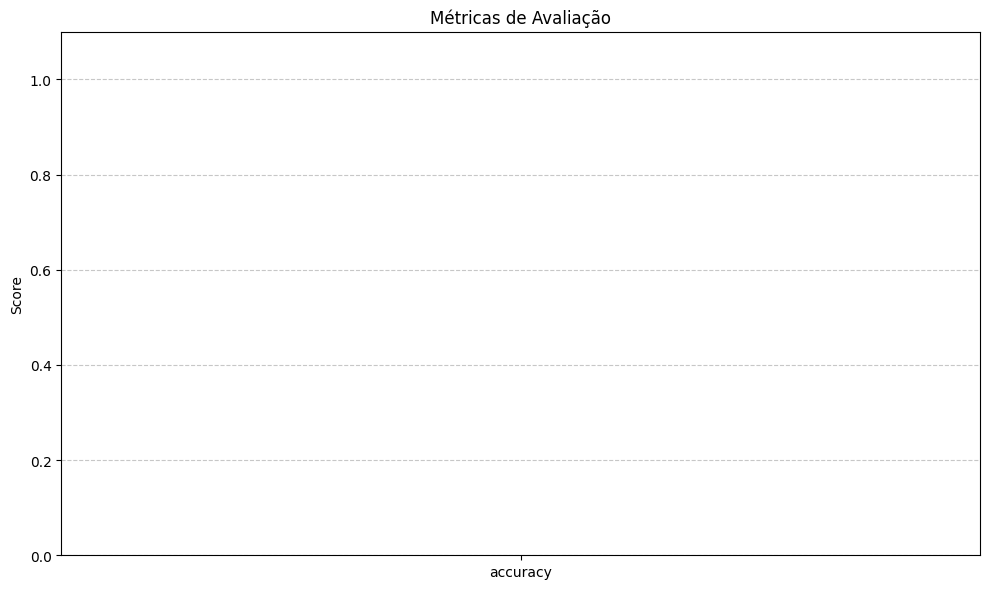

/usr/local/lib/python3.11/dist-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/usr/local/lib/python3.11/dist-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


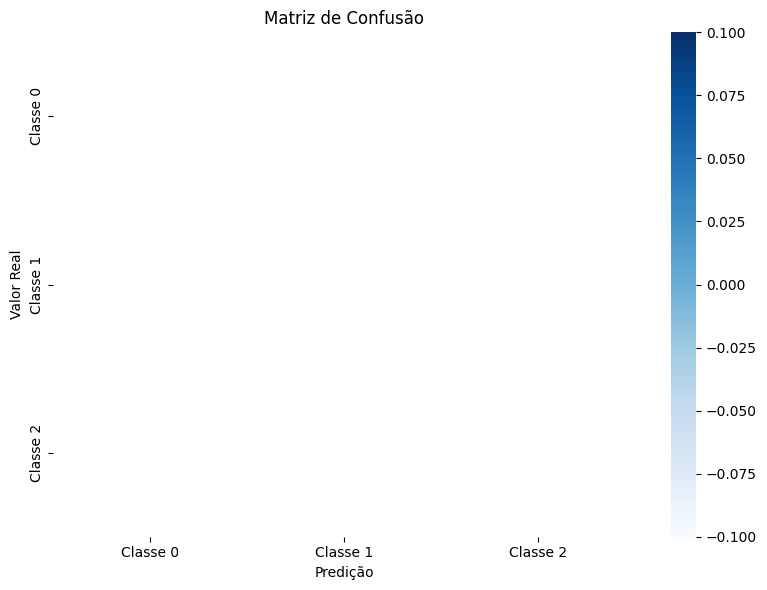

In [ ]:
final_results = manual_cross_validation(final_model, features, labels, n_folds=5)

In [ ]:
class F1Macro(tf.keras.metrics.Metric):
    """F1-macro como métrica Keras."""

    def __init__(self, num_classes=3, name="f1_macro", dtype=tf.float32, **kwargs):
        super().__init__(name=name, dtype=dtype, **kwargs)
        self.num_classes = num_classes
        # acumuladores por classe
        self.tp = self.add_weight(name="tp", shape=(num_classes,), initializer="zeros", dtype=dtype)
        self.fp = self.add_weight(name="fp", shape=(num_classes,), initializer="zeros", dtype=dtype)
        self.fn = self.add_weight(name="fn", shape=(num_classes,), initializer="zeros", dtype=dtype)

    def update_state(self, y_true, y_pred, sample_weight=None):
        # y_true esperado como ints; remove 2ª dimensão caso venha (batch,1)
        y_true = tf.cast(y_true, tf.int32)

        # Use tf.shape para trabalhar com dynamic shapes
        y_true_shape = tf.shape(y_true)

        # Remove a 2ª dimensão SE rank > 1
        if len(y_true.shape.as_list()) > 1:
            y_true = tf.squeeze(y_true, axis=-1)

        # classe prevista = argmax das probabilidades
        y_pred = tf.argmax(y_pred, axis=1, output_type=tf.int32)

        # one-hot para cálculo vetorizado
        y_true_oh = tf.one_hot(y_true, depth=self.num_classes, dtype=self.dtype)
        y_pred_oh = tf.one_hot(y_pred, depth=self.num_classes, dtype=self.dtype)

        if sample_weight is not None:
            # Garante o tipo correto primeiro
            sample_weight = tf.cast(sample_weight, self.dtype)

            # Obter o shape dinâmico de sample_weight
            sw_shape = tf.shape(sample_weight)

            # Reshape para garantir shape (batch_size, 1)
            sample_weight = tf.reshape(sample_weight, [-1, 1])

            # Difunde (broadcast) os pesos para os vetores one-hot
            y_true_oh *= sample_weight
            y_pred_oh *= sample_weight

        # contagens em lote
        tp_batch = tf.reduce_sum(y_true_oh * y_pred_oh, axis=0)
        fp_batch = tf.reduce_sum((1. - y_true_oh) * y_pred_oh, axis=0)
        fn_batch = tf.reduce_sum(y_true_oh * (1. - y_pred_oh), axis=0)

        # acumula
        self.tp.assign_add(tp_batch)
        self.fp.assign_add(fp_batch)
        self.fn.assign_add(fn_batch)

    def result(self):
        precision = tf.math.divide_no_nan(self.tp, self.tp + self.fp)
        recall = tf.math.divide_no_nan(self.tp, self.tp + self.fn)
        f1 = tf.math.divide_no_nan(2. * precision * recall, precision + recall)
        return tf.reduce_mean(f1)  # macro-average

    def reset_state(self):
        for var in (self.tp, self.fp, self.fn):
            var.assign(tf.zeros_like(var))

In [ ]:
from keras.saving import register_keras_serializable

@register_keras_serializable()
class F1Macro(tf.keras.metrics.Metric):
    """F1-macro como métrica Keras."""

    def __init__(self, num_classes=3, name="f1_macro", dtype=tf.float32, **kwargs):
        super().__init__(name=name, dtype=dtype, **kwargs)
        self.num_classes = num_classes
        # acumuladores por classe
        self.tp = self.add_weight(name="tp", shape=(num_classes,), initializer="zeros", dtype=dtype)
        self.fp = self.add_weight(name="fp", shape=(num_classes,), initializer="zeros", dtype=dtype)
        self.fn = self.add_weight(name="fn", shape=(num_classes,), initializer="zeros", dtype=dtype)

    def update_state(self, y_true, y_pred, sample_weight=None):
        # y_true esperado como ints; remove 2ª dimensão caso venha (batch,1)
        y_true = tf.cast(y_true, tf.int32)

        # Use tf.shape para trabalhar com dynamic shapes
        y_true_shape = tf.shape(y_true)

        # Remove a 2ª dimensão SE rank > 1
        if len(y_true.shape.as_list()) > 1:
            y_true = tf.squeeze(y_true, axis=-1)

        # classe prevista = argmax das probabilidades
        y_pred = tf.argmax(y_pred, axis=1, output_type=tf.int32)

        # one-hot para cálculo vetorizado
        y_true_oh = tf.one_hot(y_true, depth=self.num_classes, dtype=self.dtype)
        y_pred_oh = tf.one_hot(y_pred, depth=self.num_classes, dtype=self.dtype)

        if sample_weight is not None:
            # Garante o tipo correto primeiro
            sample_weight = tf.cast(sample_weight, self.dtype)

            # Obter o shape dinâmico de sample_weight
            sw_shape = tf.shape(sample_weight)

            # Reshape para garantir shape (batch_size, 1)
            sample_weight = tf.reshape(sample_weight, [-1, 1])

            # Difunde (broadcast) os pesos para os vetores one-hot
            y_true_oh *= sample_weight
            y_pred_oh *= sample_weight

        # contagens em lote
        tp_batch = tf.reduce_sum(y_true_oh * y_pred_oh, axis=0)
        fp_batch = tf.reduce_sum((1. - y_true_oh) * y_pred_oh, axis=0)
        fn_batch = tf.reduce_sum(y_true_oh * (1. - y_pred_oh), axis=0)

        # acumula
        self.tp.assign_add(tp_batch)
        self.fp.assign_add(fp_batch)
        self.fn.assign_add(fn_batch)

    def result(self):
        precision = tf.math.divide_no_nan(self.tp, self.tp + self.fp)
        recall = tf.math.divide_no_nan(self.tp, self.tp + self.fn)
        f1 = tf.math.divide_no_nan(2. * precision * recall, precision + recall)
        return tf.reduce_mean(f1)  # macro-average

    def reset_state(self):
        for var in (self.tp, self.fp, self.fn):
            var.assign(tf.zeros_like(var))

    # Métodos para serialização
    def get_config(self):
        config = super().get_config()
        config.update({
            "num_classes": self.num_classes
        })
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

from keras.utils import get_custom_objects
get_custom_objects()["F1Macro"] = F1Macro

In [ ]:
# Minimal Model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(10,)),
    tf.keras.layers.Dense(5, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax') # Assuming 3 classes
])

# Try compiling with the metric
try:
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=[F1Macro(num_classes=3)]) # Instantiate it
    print("Compilation successful!")

    # Optional: Try a dummy fit
    # print("Trying dummy fit...")
    # dummy_x = np.random.rand(16, 10)
    # dummy_y = np.random.randint(0, 3, size=(16,))
    # model.fit(dummy_x, dummy_y, epochs=1, verbose=0)
    # print("Dummy fit successful!")

except Exception as e:
    print(f"Error during isolated test: {e}")
    import traceback
    traceback.print_exc()

Compilation successful!


In [ ]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Mon May  5 17:46:15 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   44C    P0             28W /   72W |     193MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Deep Network basic DNN (MLP)

#### Encontra parametros ótimos (MLP)

In [ ]:
import multiprocessing
from psutil import virtual_memory

# ------------------------------------------------------------
# Configuração inicial para GPU
# ------------------------------------------------------------
print("=== Configuração do sistema ===")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU disponível: {tf.test.gpu_device_name()}")
        gpu_details = tf.config.experimental.get_device_details(gpus[0])
        print(f"GPU details: {gpu_details}")
    except RuntimeError as e:
        print(e)
else:
    print("Nenhuma GPU detectada!")

print(f"CPU cores: {multiprocessing.cpu_count()}")
ram = virtual_memory()
print(f"RAM total: {ram.total / 1e9:.1f} GB")
print("================================\n")

# ------------------------------------------------------------
# 1) Função construtora do MLP
# ------------------------------------------------------------
def build_mlp(meta, l2_val, drop, n1, n2):
    tf.keras.backend.clear_session()
    n_inputs = meta["n_features_in_"]

    with tf.device('/GPU:0'):  # Força uso da GPU
        model = tf.keras.Sequential([
            tf.keras.layers.Input(shape=(n_inputs,)),
            tf.keras.layers.Dense(n1, activation="relu",
                                  kernel_regularizer=regularizers.l2(l2_val)),
            tf.keras.layers.Dropout(drop),
            tf.keras.layers.Dense(n2, activation="relu",
                                  kernel_regularizer=regularizers.l2(l2_val)),
            tf.keras.layers.Dropout(drop),
            tf.keras.layers.Dense(3, activation="softmax")
        ])
        model.compile(optimizer="adam",
                      loss="sparse_categorical_crossentropy",
                      metrics=["accuracy", F1Macro(num_classes=3)])

    # força a criação de um grafo concreto apenas UMA vez
    model.train_function = model.make_train_function()
    model.test_function  = model.make_test_function()
    return model

# ------------------------------------------------------------
# 2) Callbacks
# ------------------------------------------------------------
early_stop = tf.keras.callbacks.EarlyStopping(
               patience=10,
               restore_best_weights=True,
               monitor="val_f1_macro", mode="max",
               verbose = 1)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
               monitor="val_loss",
               mode="min",
               factor=0.3,
               patience=4,
               min_lr=1e-6,
               verbose=1)

# ------------------------------------------------------------
# 3) Wrapper SciKeras
# ------------------------------------------------------------
keras_clf = KerasClassifier(
        model             = build_mlp,
        epochs            = 200,
        batch_size        = 64,  # Maior para GPU
        verbose           = 1,
        validation_split  = 0.20,
        callbacks=[early_stop, reduce_lr]
)

# ------------------------------------------------------------
# 4) Pipeline
# ------------------------------------------------------------
pipe = Pipeline([
        ("kbest" , SelectKBest(f_classif, k=20)),
        ("scale", StandardScaler()),
        ("clf"  , keras_clf)
])

# ------------------------------------------------------------
# 5) Espaço de busca para RandomizedSearchCV
# ------------------------------------------------------------
param_dist = {
    "clf__model__l2_val": [1e-4, 5e-4, 1e-3, 5e-3, 1e-2],
    "clf__model__drop"  : [0.25, 0.35, 0.45, 0.55],
    "clf__model__n1"    : [16, 32, 48],
    "clf__model__n2"    : [8, 16, 24],
    "kbest__k": [10, 15, 20, 25]
}

# 5-fold estratificado
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ------------------------------------------------------------
# 6) Busca aleatória
# ------------------------------------------------------------
total = len(ParameterGrid(param_dist))
n_cores = multiprocessing.cpu_count()

rand = RandomizedSearchCV(
    estimator            = pipe,
    param_distributions  = param_dist,
    n_iter               = min(total, 20),
    cv                   = cv,
    scoring              = "f1_macro",
    n_jobs               = min(n_cores, 8),
    refit                = True,
    verbose              = 0,
    random_state         = 42
)

# ------------------------------------------------------------
# 7) Execução
# ------------------------------------------------------------
print("Iniciando busca de hiperparâmetros...")
t0 = time.perf_counter()
rand.fit(features, labels)

# ------------------------------------------------------------
# 8) Resultados
# ------------------------------------------------------------
print("\n=== RESULTADOS ===")
print("Melhor F1-macro: ", rand.best_score_)
print("Hiper-parâmetros:", rand.best_params_)

t_total = time.perf_counter() - t0
print(f"\nTempo total: {t_total/60:.1f} min ({t_total:.1f} s)")

cv_times = pd.DataFrame({
        "fit (s)"  : rand.cv_results_["mean_fit_time"],
        "score (s)": rand.cv_results_["mean_score_time"]
})
print("\nTempos por fold:")
print(cv_times.describe())

# Monitoramento final de recursos
print("\n=== Status final de recursos ===")
ram = virtual_memory()
print(f"RAM disponível: {ram.available / 1e9:.1f} GB")

=== Configuração do sistema ===
Physical devices cannot be modified after being initialized
CPU cores: 12
RAM total: 56.9 GB

Iniciando busca de hiperparâmetros...


/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan]
  warnings.warn(


Epoch 1/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - accuracy: 0.5538 - f1_macro: 0.4729 - loss: 1.3742 - val_accuracy: 0.2159 - val_f1_macro: 0.1708 - val_loss: 1.5061 - learning_rate: 0.0010
Epoch 2/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7222 - f1_macro: 0.5596 - loss: 0.9776 - val_accuracy: 0.6163 - val_f1_macro: 0.4999 - val_loss: 1.2758 - learning_rate: 0.0010
Epoch 3/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7841 - f1_macro: 0.6589 - loss: 0.8186 - val_accuracy: 0.7242 - val_f1_macro: 0.5441 - val_loss: 1.0620 - learning_rate: 0.0010
Epoch 4/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8406 - f1_macro: 0.7778 - loss: 0.6829 - val_accuracy: 0.6330 - val_f1_macro: 0.4245 - val_loss: 1.0789 - learning_rate: 0.0010
Epoch 5/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8528 - f1_macro: 0.8149 - loss: 0.6214 - val_accuracy: 0.6026 - val_f1_macro: 0.3747 - val_loss: 1.1657 - learning_rate: 0.0010
Epoch 6/200
64/64 ━━━━━━━━━━━━━━━━

#### Executa com parâmetros ótimos (MLP)

In [ ]:
import tensorflow as tf
import multiprocessing
import time
from sklearn.model_selection import StratifiedKFold, cross_validate
import pandas as pd
from psutil import virtual_memory

# ------------------------------------------------------------
# Configuração inicial para GPU
# ------------------------------------------------------------
print("=== Configuração do sistema ===")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU disponível: {tf.test.gpu_device_name()}")
        gpu_details = tf.config.experimental.get_device_details(gpus[0])
        print(f"GPU details: {gpu_details}")
    except RuntimeError as e:
        print(e)
else:
    print("Nenhuma GPU detectada!")

print(f"CPU cores: {multiprocessing.cpu_count()}")
ram = virtual_memory()
print(f"RAM total: {ram.total / 1e9:.1f} GB")
print("================================\n")

# ------------------------------------------------------------
# Cross-validation com o melhor estimador
# ------------------------------------------------------------

# O melhor estimador já obtido do RandomizedSearchCV
best_final = rand.best_estimator_

# 5-fold estratificado
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Métricas para avaliar
scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro"
}

print("\nIniciando validação cruzada final...")
print(f"Melhor estimador: {rand.best_estimator_.get_params()['clf__model__n1']}-{rand.best_estimator_.get_params()['clf__model__n2']} neurons")
print(f"Melhores parâmetros: {rand.best_params_}\n")

# Execute cross-validation
t0 = time.perf_counter()

# Use todos os cores disponíveis para paralelização
n_cores = multiprocessing.cpu_count()

cv_res = cross_validate(best_final, features, labels,
                        cv=cv,
                        scoring=scoring,
                        n_jobs=min(n_cores, 8),  # Limite para não sobrecarregar
                        return_train_score=False,
                        verbose=1)

t_total = time.perf_counter() - t0

# ------------------------------------------------------------
# Resultados
# ------------------------------------------------------------
print("\n=== RESULTADOS DA VALIDAÇÃO CRUZADA ===")
print(f"Tempo de execução: {t_total/60:.1f} min ({t_total:.1f} s)\n")

# Mostrar médias e desvio padrão
print("Métricas por fold:")
print("-" * 50)
for m in scoring:
    vals = cv_res[f"test_{m}"]
    print(f"{m:15s}: mean = {vals.mean():.4f} | std = {vals.std():.4f}")

print("\nResumo das médias:")
print("-" * 30)
for m, v in scoring.items():
    print(f"{m:16s}: {cv_res[f'test_{m}'].mean():.4f}")

# Criar DataFrame com todos os resultados
results_df = pd.DataFrame()
for metric in scoring:
    results_df[metric] = cv_res[f'test_{metric}']

results_df['fold'] = range(1, 6)
results_df = results_df.set_index('fold')

print("\nResultados detalhados por fold:")
print(results_df.round(4))

# Salvar resultados em CSV (opcional)
# results_df.to_csv('validacao_final_resultados.csv')

# Mostrar uso de memória final
ram = virtual_memory()
print(f"\n=== Status final de recursos ===")
print(f"RAM disponível: {ram.available / 1e9:.1f} GB")

=== Configuração do sistema ===
Physical devices cannot be modified after being initialized
CPU cores: 12
RAM total: 56.9 GB


Iniciando validação cruzada final...
Melhor estimador: 32-16 neurons
Melhores parâmetros: {'kbest__k': 10, 'clf__model__n2': 16, 'clf__model__n1': 32, 'clf__model__l2_val': 0.01, 'clf__model__drop': 0.35}



[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.


BrokenProcessPool: A task has failed to un-serialize. Please ensure that the arguments of the function are all picklable.